# Exploratory Data Analysis

## Objective

This notebook explores the canton-year analytical dataset created during the
data-preparation stage.

The analysis focuses on identifying the variables and transformations that are
most relevant for modelling the home-ownership rate across Swiss cantons.

The EDA has four main objectives:

1. Analyse the distribution and variation of the home-ownership target.
2. Examine household-structure features and their relationship with the target.
3. Explore the demographic structure of the cantons.
4. Define a compact and interpretable feature set for the modelling stage.

The analytical unit is one canton-year observation, covering 26 Swiss cantons
from 2019 to 2024 (156 observations).

In [1]:
# Standard library imports
import sys
from pathlib import Path

# Third-party imports
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# Resolve the project root from the notebook directory.
PROJECT_ROOT = Path("..").resolve()

# Add the project root to the Python path so reusable project
# components can be imported from the src package.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data.ingestion import load_dataset

In [2]:
# Define the path to the processed analytical dataset.
ANALYTICAL_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "canton_year_analytical_dataset_2019_2024.csv"
)

# Load the analytical dataset created during data preparation.
df = pd.read_csv(ANALYTICAL_DATA_PATH)

print(f"Dataset shape: {df.shape}")
print(f"Number of cantons: {df['GEO'].nunique()}")
print(f"Number of years: {df['YEAR'].nunique()}")

Dataset shape: (156, 113)
Number of cantons: 26
Number of years: 6


In [3]:
# Inspect the main identifiers and modelling target.
df[
    ["YEAR", "GEO", "CANTON", "HOME_OWNERSHIP_RATE"]
].head()

,YEAR,GEO,CANTON,HOME_OWNERSHIP_RATE
0,2019,CH040,Zürich,27.7
1,2019,CH021,Bern / Berne,38.8
2,2019,CH061,Luzern,34.4
3,2019,CH062,Uri,42.9
4,2019,CH063,Schwyz,39.4


## 1. Target Analysis

The modelling target is the home-ownership rate at canton-year level.

Before analysing potential predictors, the distribution of the target and its
variation across cantons and years are examined. This provides context for the
subsequent feature analysis and modelling strategy.

In [4]:
# Summarise the distribution of the modelling target.
df["HOME_OWNERSHIP_RATE"].describe()

count    156.000000
mean      39.737821
std        9.540348
min       14.000000
25%       34.000000
50%       41.550000
75%       46.150000
max       58.000000
Name: HOME_OWNERSHIP_RATE, dtype: float64

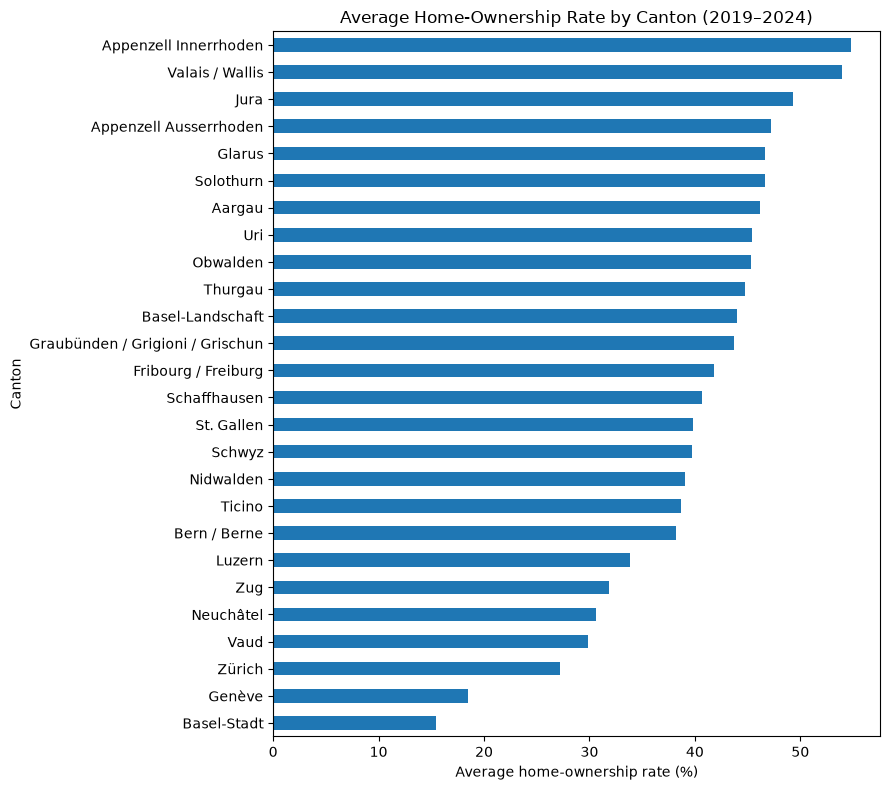

In [5]:
# Calculate the average home-ownership rate for each canton
# across the complete 2019–2024 observation period.
home_ownership_by_canton = (
    df.groupby("CANTON")["HOME_OWNERSHIP_RATE"]
    .mean()
    .sort_values()
)

# Visualise geographic differences in the modelling target.
plt.figure(figsize=(9, 8))

home_ownership_by_canton.plot(
    kind="barh",
)

plt.xlabel("Average home-ownership rate (%)")
plt.ylabel("Canton")
plt.title("Average Home-Ownership Rate by Canton (2019–2024)")

plt.tight_layout()
plt.show()

In [6]:
# Define the path to the original BFS home-ownership dataset.
HOME_OWNERSHIP_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "bfs"
    / "housing"
    / "home-ownership-rate-by-canton"
    / "BFS_HOME_OWNERSHIP_RATE_BY_CANTON-2019_2024.csv"
)

# Load the original target dataset.
home_ownership_raw = load_dataset(HOME_OWNERSHIP_PATH)

# Extract the official Swiss home-ownership rate.
# Switzerland is used only as an EDA benchmark and is not part
# of the canton-level modelling dataset.
switzerland_home_ownership = home_ownership_raw[
    home_ownership_raw["GEO"] == "CH"
][
    ['\ufeff"TIME_PERIOD"', "OBS_VALUE"]
].copy()

switzerland_home_ownership = switzerland_home_ownership.rename(
    columns={
        '\ufeff"TIME_PERIOD"': "YEAR",
        "OBS_VALUE": "HOME_OWNERSHIP_RATE",
    }
)

switzerland_home_ownership

,YEAR,HOME_OWNERSHIP_RATE
26,2019,36.4
53,2020,36.2
80,2021,36.3
107,2022,35.9
134,2023,35.8
161,2024,35.7


In [7]:
# Calculate the average of the official Swiss home-ownership rate
# over the same 2019–2024 period used for the canton comparison.
switzerland_average = (
    switzerland_home_ownership["HOME_OWNERSHIP_RATE"].mean()
)

print(f"Switzerland average (2019–2024): {switzerland_average:.2f}%")

Switzerland average (2019–2024): 36.05%


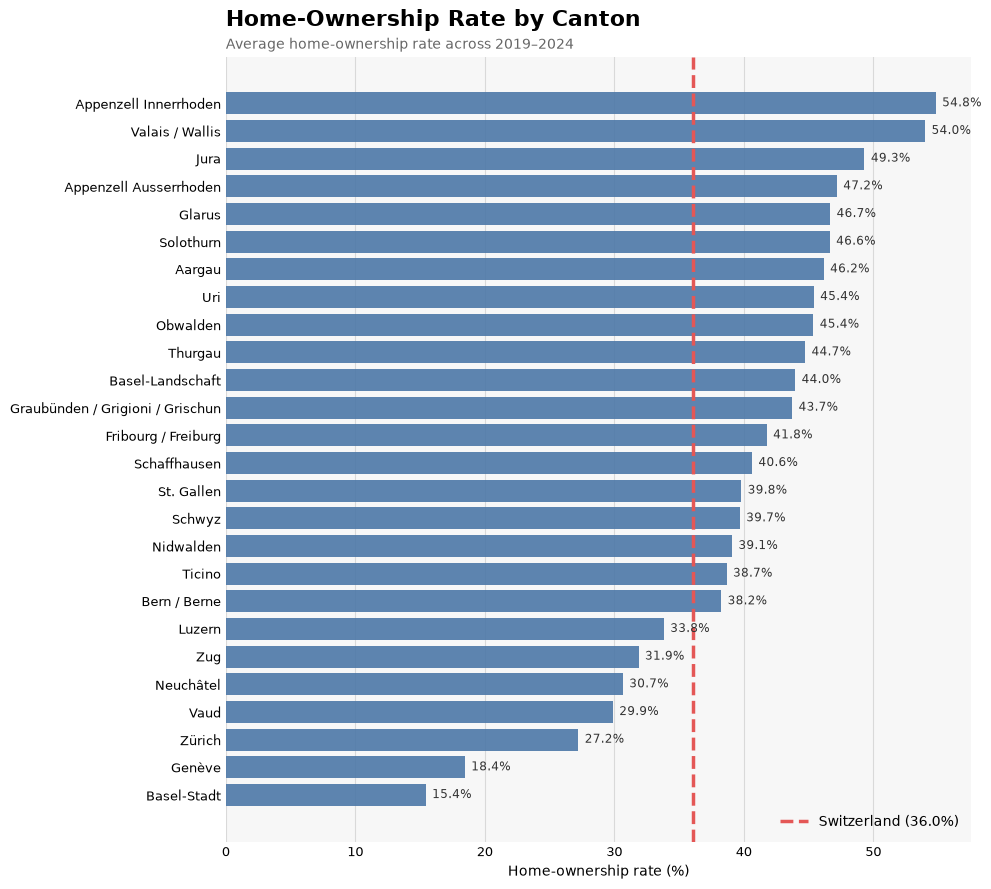

In [8]:
# Calculate the average home-ownership rate for each canton
# across the complete 2019–2024 observation period.
home_ownership_by_canton = (
    df.groupby("CANTON")["HOME_OWNERSHIP_RATE"]
    .mean()
    .sort_values()
)

# Calculate the unweighted average across all canton-year observations.
# This is a reference average, not the official aggregated Swiss rate.
canton_average = df["HOME_OWNERSHIP_RATE"].mean()


# Define a consistent visual palette for the EDA.
BAR_COLOR = "#4C78A8"
REFERENCE_COLOR = "#E45756"
GRID_COLOR = "#D9D9D9"
BACKGROUND_COLOR = "#F7F7F7"


# Create the figure.
fig, ax = plt.subplots(figsize=(10, 9))

fig.patch.set_facecolor("white")
ax.set_facecolor(BACKGROUND_COLOR)


# Plot canton averages.
bars = ax.barh(
    home_ownership_by_canton.index,
    home_ownership_by_canton.values,
    color=BAR_COLOR,
    alpha=0.9,
)


# Add the official Swiss reference as a contrasting benchmark.
ax.axvline(
    switzerland_average,
    color=REFERENCE_COLOR,
    linestyle="--",
    linewidth=2.5,
    label=f"Switzerland ({switzerland_average:.1f}%)",
)


# Add values at the end of each bar.
for bar in bars:
    value = bar.get_width()

    ax.text(
        value + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        fontsize=8.5,
        color="#333333",
    )

# Title and subtitle.
ax.set_title(
    "Home-Ownership Rate by Canton",
    fontsize=16,
    fontweight="bold",
    loc="left",
    pad=22,
)

ax.text(
    0,
    1.01,
    "Average home-ownership rate across 2019–2024",
    transform=ax.transAxes,
    fontsize=10,
    color="#666666",
)


# Axis formatting.
ax.set_xlabel(
    "Home-ownership rate (%)",
    fontsize=10,
)

ax.set_ylabel("")


# ggplot-like grid.
ax.grid(
    axis="x",
    color=GRID_COLOR,
    linewidth=0.8,
)

ax.set_axisbelow(True)


# Remove unnecessary borders.
for spine in ax.spines.values():
    spine.set_visible(False)


# Clean tick appearance.
ax.tick_params(
    axis="both",
    length=0,
    labelsize=9,
)


# Highlight the reference line in the legend.
ax.legend(
    frameon=False,
    loc="lower right",
)


plt.tight_layout()
plt.show()

***REPORT NOTE:*** The official Swiss home-ownership rate was retained as an external descriptive benchmark. A simple average across cantonal rates was deliberately not used as a national estimate because it would assign equal weight to cantons with substantially different population and housing structures.

In [9]:
# Calculate the mean home-ownership rate of each canton
# across the complete observation period.
canton_means = (
    df.groupby("CANTON")["HOME_OWNERSHIP_RATE"]
    .mean()
)

# Measure variation between cantons using the standard deviation
# of the canton-level means.
between_canton_std = canton_means.std()


# Calculate the temporal standard deviation within each canton.
within_canton_std = (
    df.groupby("CANTON")["HOME_OWNERSHIP_RATE"]
    .std()
)

# Summarise the typical within-canton temporal variation.
mean_within_canton_std = within_canton_std.mean()


print(
    f"Between-canton standard deviation: "
    f"{between_canton_std:.2f} percentage points"
)

print(
    f"Average within-canton standard deviation: "
    f"{mean_within_canton_std:.2f} percentage points"
)

print(
    f"Between / within variation ratio: "
    f"{between_canton_std / mean_within_canton_std:.1f}x"
)

Between-canton standard deviation: 9.64 percentage points
Average within-canton standard deviation: 0.91 percentage points
Between / within variation ratio: 10.5x


**Interpretation.** Home-ownership rates show substantially greater variation
between cantons than within individual cantons over time. The standard deviation
between canton-level averages is 9.64 percentage points, compared with an average
within-canton temporal standard deviation of 0.91 percentage points. The resulting
ratio of approximately 10.5 indicates that the structure of the target is
predominantly cross-sectional rather than temporal.

This panel structure must be considered when defining the model validation
strategy, since observations from different years of the same canton are not
independent.

## Geographic Distribution

The home-ownership rate exhibits substantially greater variation between cantons
than within cantons over time. This section examines the geographic distribution
of these differences across Switzerland using official canton boundaries from
swisstopo.

In [10]:
# Define the path to the official swisstopo administrative boundaries.
BOUNDARIES_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "swisstopo"
    / "swissboundaries3d"
    / "swissBOUNDARIES3D_1_5_LV95_LN02.gpkg"
)

# Inspect the available layers before loading the canton geometries.
# A GeoPackage can contain multiple geographic layers.
layers = gpd.list_layers(BOUNDARIES_PATH)

layers

,name,geometry_type
0,tlm_hoheitsgrenze,LineString Z
1,tlm_hoheitsgebiet,MultiPolygon Z
2,tlm_bezirksgebiet,MultiPolygon Z
3,tlm_landesgebiet,MultiPolygon Z
4,tlm_kantonsgebiet,MultiPolygon Z


In [11]:
# Load the canton-level geometries from the official
# swisstopo swissBOUNDARIES3D GeoPackage.
cantons_geo = gpd.read_file(
    BOUNDARIES_PATH,
    layer="tlm_kantonsgebiet",
)

print(f"Shape: {cantons_geo.shape}")
print(f"CRS: {cantons_geo.crs}")

cantons_geo.head()

Shape: (26, 20)
CRS: EPSG:2056


,uuid,datum_aenderung,datum_erstellung,erstellung_jahr,erstellung_monat,grund_aenderung,herkunft,herkunft_jahr,herkunft_monat,revision_jahr,revision_monat,revision_qualitaet,objektart,kantonsnummer,see_flaeche,kantonsflaeche,name,icc,einwohnerzahl,geometry
0,{C0A13B16-7F38-4093-AE0D-D3483C1C6C34},2025-11-19,2012-10-26,2012,10,Verbessert,swisstopo,2026,1,2026,1,TGMG_2026_Akt,Kanton,25,3661.0,28249.0,Genève,CH,531102,MULTIPOLYGON Z (((2498882.997 1130411.111 460....
1,{87370D3F-DBBE-4D05-AF85-C358C3924B3D},2025-11-19,2012-10-26,2012,10,Verbessert,swisstopo,2026,1,2026,1,TGMG_2026_Akt,Kanton,20,13119.0,99433.0,Thurgau,CH,299509,MULTIPOLYGON Z (((2707936.269 1279243.83 395.0...
2,{54B25E50-30A7-4995-ADE3-5FFF6E13A995},2025-11-19,2012-10-26,2012,10,Verbessert,swisstopo,2026,1,2026,1,TGMG_2026_Akt,Kanton,23,1060.0,522464.0,Valais,CH,371288,MULTIPOLYGON Z (((2679716.418 1153451.251 3024...
3,{E11CD2CA-2E2D-415C-8789-C10D7C26E441},2025-11-19,2012-10-26,2012,10,Verbessert,swisstopo,2026,1,2026,1,TGMG_2026_Akt,Kanton,19,870.0,140380.0,Aargau,CH,735808,MULTIPOLYGON Z (((2673541.703 1233505.879 386....
4,{F06DD902-ABC6-4331-81F5-19B85D091E5E},2025-11-19,2012-10-26,2012,10,Verbessert,swisstopo,2026,1,2026,1,TGMG_2026_Akt,Kanton,5,5654.0,90788.0,Schwyz,CH,168931,MULTIPOLYGON Z (((2714000.935 1197614.674 2609...


In [12]:
# Inspect the canton identifiers provided by swisstopo.
# Sorting by canton number makes it easier to verify whether
# the numbering follows the official BFS canton coding.
cantons_geo[
    ["kantonsnummer", "name"]
].sort_values("kantonsnummer")

,kantonsnummer,name
5,1,Zürich
22,2,Bern
16,3,Luzern
9,4,Uri
4,5,Schwyz
6,6,Obwalden
10,7,Nidwalden
8,8,Glarus
18,9,Zug
7,10,Fribourg


In [13]:
# Load the canton reference table already used during data preparation.
# This provides the link between the analytical GEO identifiers
# and the official canton information.
CANTON_LOOKUP_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "bfs"
    / "reference"
    / "GEO_CANTON_LOOKUP.xlsx"
)

canton_lookup = pd.read_excel(CANTON_LOOKUP_PATH)

canton_lookup.head()

,CODE,LABEL_EN,LABEL_FR,LABEL_DE,LABEL_IT
0,CH,Switzerland,Suisse,Schweiz,Svizzera
1,CH011,Vaud,Vaud,Waadt,Vaud
2,CH012,Valais,Valais,Wallis,Vallese
3,CH013,Genève,Genève,Genf,Ginevra
4,CH021,Bern,Berne,Bern,Berna


In [14]:
# Exclude the national Switzerland record because the geographic
# layer contains only the 26 cantons.
canton_lookup_map = canton_lookup[
    canton_lookup["CODE"] != "CH"
].copy()

# Check which lookup language provides the best match with the
# canton names used by swisstopo.
for label_column in ["LABEL_EN", "LABEL_FR", "LABEL_DE", "LABEL_IT"]:
    matched_names = cantons_geo["name"].isin(
        canton_lookup_map[label_column]
    ).sum()

    print(
        f"{label_column}: "
        f"{matched_names}/26 canton names matched"
    )

LABEL_EN: 25/26 canton names matched
LABEL_FR: 8/26 canton names matched
LABEL_DE: 20/26 canton names matched
LABEL_IT: 4/26 canton names matched


In [15]:
# Harmonise the only naming difference between the swisstopo
# canton geometries and the BFS English canton labels.
cantons_geo["name_bfs"] = cantons_geo["name"].replace(
    {
        "Fribourg": "Freiburg",
    }
)

# Verify that all 26 swisstopo canton names now match
# the BFS canton reference table.
matched_cantons = cantons_geo["name_bfs"].isin(
    canton_lookup_map["LABEL_EN"]
).sum()

print(f"Matched cantons: {matched_cantons}/26")

assert matched_cantons == 26

Matched cantons: 26/26


In [16]:
# Add the BFS GEO identifier to the swisstopo canton geometries.
# The harmonised canton name is used only as a bridge between
# the two official data sources.
cantons_geo = cantons_geo.merge(
    canton_lookup_map[
        ["CODE", "LABEL_EN"]
    ],
    left_on="name_bfs",
    right_on="LABEL_EN",
    how="left",
    validate="one_to_one",
)

# Rename CODE to GEO so it matches the analytical dataset.
cantons_geo = cantons_geo.rename(
    columns={"CODE": "GEO"}
)

# Validate the geographic integration.
assert cantons_geo["GEO"].notna().all()
assert cantons_geo["GEO"].nunique() == 26

cantons_geo[
    ["GEO", "name"]
].sort_values("GEO").head()

,GEO,name
15,CH011,Vaud
2,CH012,Valais
0,CH013,Genève
22,CH021,Bern
7,CH022,Fribourg


In [17]:
# Calculate the average home-ownership rate for each canton
# across the complete 2019–2024 observation period.
home_ownership_map_data = (
    df.groupby("GEO", as_index=False)["HOME_OWNERSHIP_RATE"]
    .mean()
)

# Combine the statistical data with the canton geometries.
home_ownership_map = cantons_geo.merge(
    home_ownership_map_data,
    on="GEO",
    how="left",
    validate="one_to_one",
)

# Validate that every canton received a home-ownership value.
assert len(home_ownership_map) == 26
assert home_ownership_map["HOME_OWNERSHIP_RATE"].notna().all()

home_ownership_map[
    ["GEO", "name", "HOME_OWNERSHIP_RATE"]
].sort_values(
    "HOME_OWNERSHIP_RATE",
    ascending=False,
).head()

,GEO,name,HOME_OWNERSHIP_RATE
25,CH054,Appenzell Innerrhoden,54.816667
2,CH012,Valais,54.000000
13,CH025,Jura,49.316667
12,CH053,Appenzell Ausserrhoden,47.183333
8,CH051,Glarus,46.666667


### Geographic Distribution of Home Ownership

The map below shows the average home-ownership rate of each Swiss canton over
the 2019–2024 period. A continuous colour scale is used to preserve the
underlying variation in the target without introducing arbitrary geographic
categories.

In [18]:
# Map BFS GEO identifiers to the standard canton abbreviations.
geo_to_abbreviation = {
    "CH011": "VD",
    "CH012": "VS",
    "CH013": "GE",
    "CH021": "BE",
    "CH022": "FR",
    "CH023": "SO",
    "CH024": "BS",
    "CH025": "BL",
    "CH031": "AG",
    "CH032": "NE",
    "CH033": "JU",
    "CH040": "ZH",
    "CH051": "GL",
    "CH052": "SH",
    "CH053": "AR",
    "CH054": "AI",
    "CH055": "SG",
    "CH056": "GR",
    "CH057": "TG",
    "CH061": "LU",
    "CH062": "UR",
    "CH063": "SZ",
    "CH064": "OW",
    "CH065": "NW",
    "CH066": "ZG",
    "CH070": "TI",
}

home_ownership_map["ABBR"] = home_ownership_map["GEO"].map(
    geo_to_abbreviation
)

assert home_ownership_map["ABBR"].notna().all()

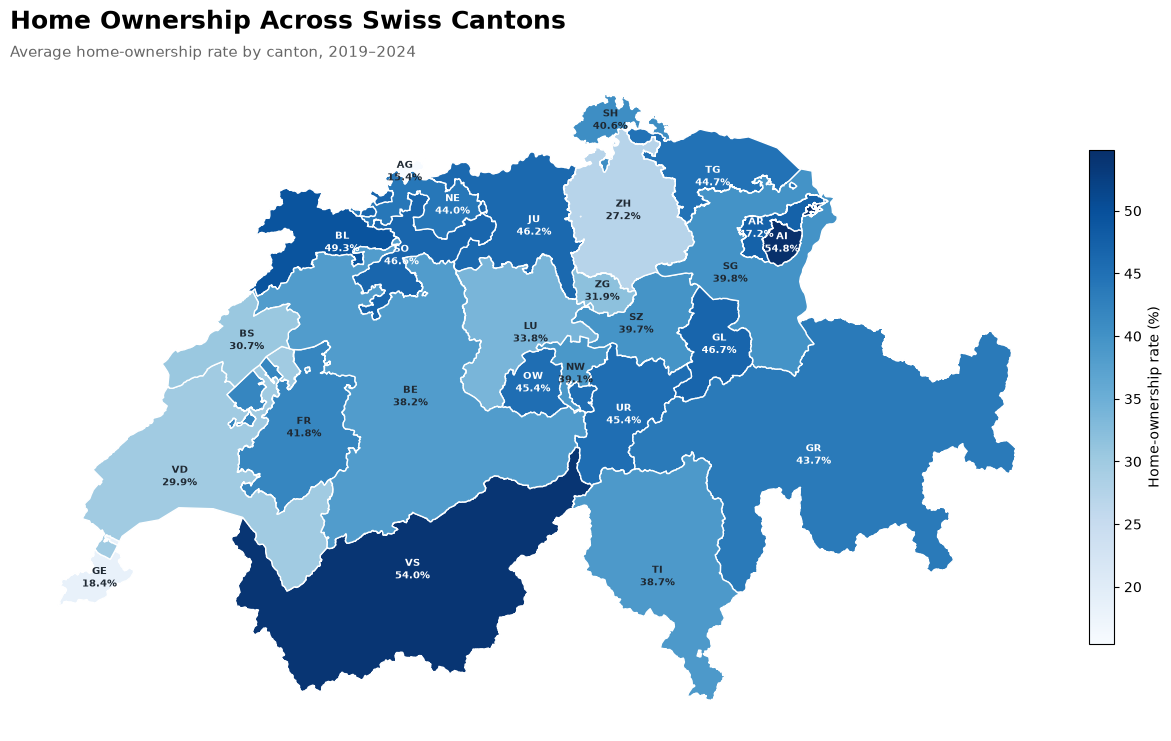

In [19]:
# Create the final canton-level choropleth.
fig, ax = plt.subplots(figsize=(13, 8))

fig.patch.set_facecolor("white")
ax.set_facecolor("white")

home_ownership_map.plot(
    column="HOME_OWNERSHIP_RATE",
    cmap="Blues",
    linewidth=1.0,
    edgecolor="white",
    legend=True,
    legend_kwds={
        "label": "Home-ownership rate (%)",
        "shrink": 0.65,
        "pad": 0.02,
    },
    ax=ax,
)

# Add canton abbreviation and home-ownership rate.
# The text colour changes according to the underlying value
# to maintain sufficient contrast across the colour scale.
for _, row in home_ownership_map.iterrows():
    point = row.geometry.representative_point()

    # Use white labels on dark areas and dark labels on light areas.
    text_color = (
        "white"
        if row["HOME_OWNERSHIP_RATE"] >= 43
        else "#1F2933"
    )

    ax.text(
        point.x,
        point.y,
        f"{row['ABBR']}\n{row['HOME_OWNERSHIP_RATE']:.1f}%",
        ha="center",
        va="center",
        fontsize=7.5,
        fontweight="bold",
        color=text_color,
    )

ax.set_title(
    "Home Ownership Across Swiss Cantons",
    fontsize=18,
    fontweight="bold",
    loc="left",
    pad=25,
)

ax.text(
    0,
    1.01,
    "Average home-ownership rate by canton, 2019–2024",
    transform=ax.transAxes,
    fontsize=11,
    color="#666666",
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

## Household Structure

Household composition may help explain differences in home ownership across
Swiss cantons. This section examines the relationship between household-size
structure and the home-ownership rate.

The six household-size shares represent a composition and therefore sum to one.
Consequently, they are not statistically independent and their relationships
must be considered before model specification.

In [20]:
# Define the household features available in the analytical dataset.
household_share_features = [
    "SHARE_1_PERSON_HOUSEHOLDS",
    "SHARE_2_PERSON_HOUSEHOLDS",
    "SHARE_3_PERSON_HOUSEHOLDS",
    "SHARE_4_PERSON_HOUSEHOLDS",
    "SHARE_5_PERSON_HOUSEHOLDS",
    "SHARE_6_PLUS_PERSON_HOUSEHOLDS",
]

household_features = [
    "TOTAL_HOUSEHOLDS",
    *household_share_features,
]

# Calculate the Pearson correlation between each household feature
# and the home-ownership target.
household_target_correlations = (
    df[
        household_features
        + ["HOME_OWNERSHIP_RATE"]
    ]
    .corr()["HOME_OWNERSHIP_RATE"]
    .drop("HOME_OWNERSHIP_RATE")
    .sort_values()
)

household_target_correlations

TOTAL_HOUSEHOLDS                 -0.527261
SHARE_3_PERSON_HOUSEHOLDS        -0.411222
SHARE_1_PERSON_HOUSEHOLDS        -0.158080
SHARE_6_PLUS_PERSON_HOUSEHOLDS   -0.082895
SHARE_4_PERSON_HOUSEHOLDS        -0.048310
SHARE_5_PERSON_HOUSEHOLDS         0.224023
SHARE_2_PERSON_HOUSEHOLDS         0.359463
Name: HOME_OWNERSHIP_RATE, dtype: float64

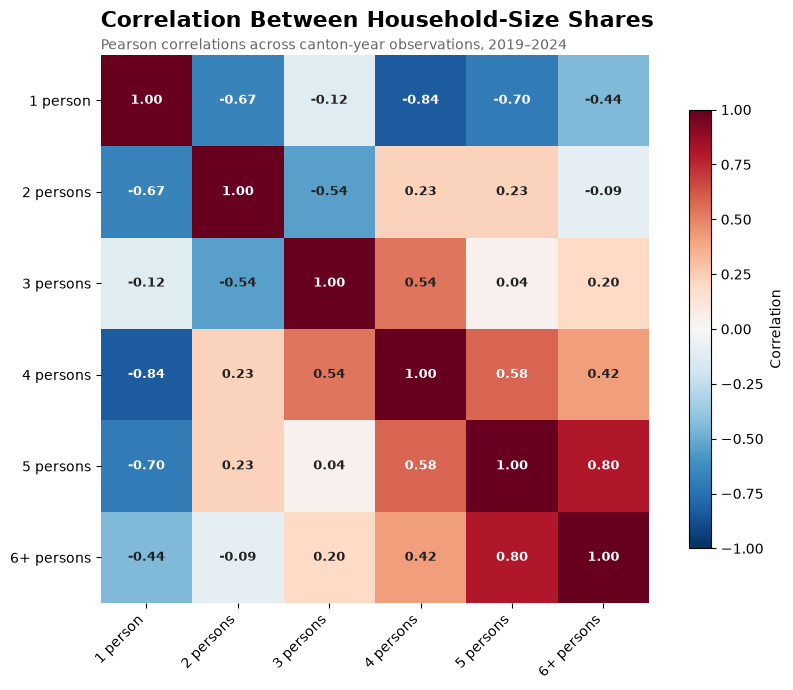

In [21]:
# Calculate the correlation matrix between household composition features.
# This helps identify dependencies between household-size shares before
# selecting variables for the modelling stage.
household_corr_matrix = df[
    household_share_features
].corr()

# Create a clean correlation heatmap using Matplotlib.
fig, ax = plt.subplots(figsize=(9, 7))

fig.patch.set_facecolor("white")
ax.set_facecolor(BACKGROUND_COLOR)

im = ax.imshow(
    household_corr_matrix,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
)

# Use shorter labels to improve readability.
household_labels = [
    "1 person",
    "2 persons",
    "3 persons",
    "4 persons",
    "5 persons",
    "6+ persons",
]

ax.set_xticks(range(len(household_labels)))
ax.set_yticks(range(len(household_labels)))

ax.set_xticklabels(
    household_labels,
    rotation=45,
    ha="right",
)

ax.set_yticklabels(household_labels)

# Display the correlation coefficient inside each cell.
for i in range(len(household_labels)):
    for j in range(len(household_labels)):
        value = household_corr_matrix.iloc[i, j]

        text_color = (
            "white"
            if abs(value) > 0.55
            else "#222222"
        )

        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=9,
            fontweight="bold",
        )

ax.set_title(
    "Correlation Between Household-Size Shares",
    fontsize=16,
    fontweight="bold",
    loc="left",
    pad=20,
)

ax.text(
    0,
    1.01,
    "Pearson correlations across canton-year observations, 2019–2024",
    transform=ax.transAxes,
    fontsize=10,
    color="#666666",
)

colorbar = fig.colorbar(
    im,
    ax=ax,
    shrink=0.8,
)

colorbar.set_label("Correlation")

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

***REPORT NOTE:*** 

Household-size shares exhibit substantial multicollinearity. Several pairwise correlations exceed |0.7|, while the six shares are also compositionally constrained to sum to one. Consequently, all household shares should not be included simultaneously in an unregularized linear model.

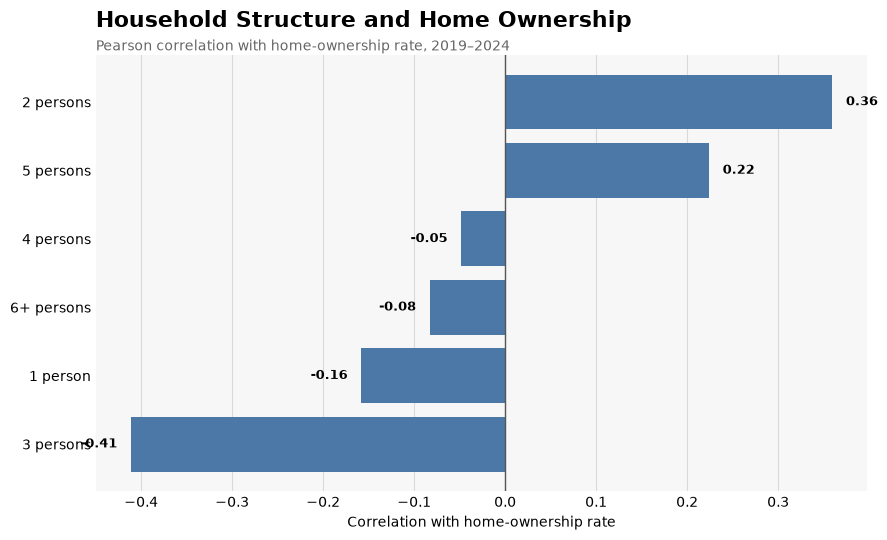

In [22]:
# Exclude TOTAL_HOUSEHOLDS from this visualization because it mainly
# represents canton size rather than household composition.
household_share_target_corr = (
    household_target_correlations[
        household_share_features
    ]
    .sort_values()
)

# Use shorter labels for presentation.
display_labels = {
    "SHARE_1_PERSON_HOUSEHOLDS": "1 person",
    "SHARE_2_PERSON_HOUSEHOLDS": "2 persons",
    "SHARE_3_PERSON_HOUSEHOLDS": "3 persons",
    "SHARE_4_PERSON_HOUSEHOLDS": "4 persons",
    "SHARE_5_PERSON_HOUSEHOLDS": "5 persons",
    "SHARE_6_PLUS_PERSON_HOUSEHOLDS": "6+ persons",
}

plot_labels = [
    display_labels[feature]
    for feature in household_share_target_corr.index
]

fig, ax = plt.subplots(figsize=(9, 5.5))

fig.patch.set_facecolor("white")
ax.set_facecolor(BACKGROUND_COLOR)

bars = ax.barh(
    plot_labels,
    household_share_target_corr.values,
    color=BAR_COLOR,
)

# Add the correlation value next to each bar.
for bar, value in zip(
    bars,
    household_share_target_corr.values,
):
    x_position = (
        value + 0.015
        if value >= 0
        else value - 0.015
    )

    ax.text(
        x_position,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}",
        va="center",
        ha="left" if value >= 0 else "right",
        fontsize=9,
        fontweight="bold",
    )

# Zero separates positive and negative associations.
ax.axvline(
    0,
    color="#555555",
    linewidth=1,
)

ax.set_title(
    "Household Structure and Home Ownership",
    fontsize=16,
    fontweight="bold",
    loc="left",
    pad=20,
)

ax.text(
    0,
    1.01,
    "Pearson correlation with home-ownership rate, 2019–2024",
    transform=ax.transAxes,
    fontsize=10,
    color="#666666",
)

ax.set_xlabel("Correlation with home-ownership rate")
ax.set_ylabel("")

ax.grid(
    axis="x",
    color=GRID_COLOR,
    linewidth=0.8,
)

ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(
    axis="both",
    length=0,
)

plt.tight_layout()
plt.show()

## Demographic Structure

The demographic source provides population counts for each individual age from
0 to 100+ years. Using all age variables directly would result in a
high-dimensional feature space relative to the 156 canton-year observations.

Rather than defining age groups a priori, the age structure is first examined
at single-year resolution to identify broader demographic patterns that can
inform subsequent feature engineering.

In [23]:
# Identify the single-year age columns contained in the
# demographic component of the analytical dataset.
age_columns = [
    column
    for column in df.columns
    if (
        column == "0 years"
        or column == "1 year"
        or column.endswith(" years")
        or column == "100 years or older"
    )
]

print(f"Number of age columns: {len(age_columns)}")
print("First age columns:", age_columns[:10])
print("Last age columns:", age_columns[-10:])

Number of age columns: 101
First age columns: ['0 years', '1 year', '2 years', '3 years', '4 years', '5 years', '6 years', '7 years', '8 years', '9 years']
Last age columns: ['91 years', '92 years', '93 years', '94 years', '95 years', '96 years', '97 years', '98 years', '99 years', '100 years or older']


In [24]:
# Convert each single-year age count into a share of the canton population.
# This removes the effect of canton size and allows demographic structures
# to be compared across cantons.
age_shares = df[age_columns].div(
    df["TOTAL_POPULATION"],
    axis=0,
)

# Calculate the correlation between each age share and
# the home-ownership rate.
age_target_correlations = age_shares.apply(
    lambda age_share: age_share.corr(
        df["HOME_OWNERSHIP_RATE"]
    )
)

# Create a numeric age index for visualization.
# The final 100+ category is represented as age 100.
age_target_correlations.index = range(101)

age_target_correlations.head()

0   -0.102884
1   -0.080222
2   -0.045039
3   -0.001065
4    0.052749
dtype: float64

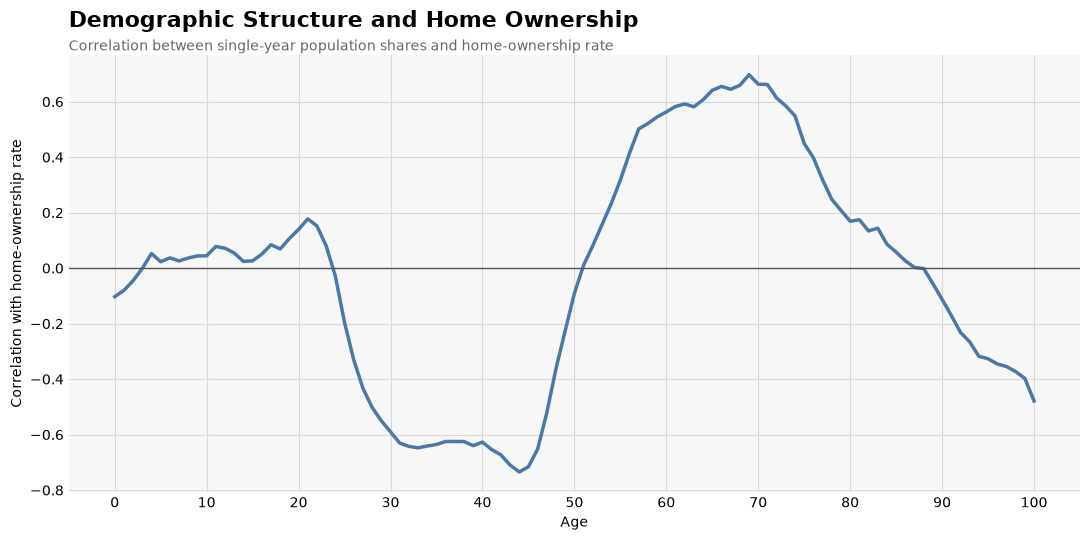

In [25]:
# Visualise how the relationship with home ownership changes
# across the complete age distribution.
fig, ax = plt.subplots(figsize=(11, 5.5))

fig.patch.set_facecolor("white")
ax.set_facecolor(BACKGROUND_COLOR)

ax.plot(
    age_target_correlations.index,
    age_target_correlations.values,
    color=BAR_COLOR,
    linewidth=2.5,
)

# Add a zero-reference line to distinguish positive and
# negative associations with the target.
ax.axhline(
    0,
    color="#555555",
    linewidth=1,
)

ax.set_title(
    "Demographic Structure and Home Ownership",
    fontsize=16,
    fontweight="bold",
    loc="left",
    pad=20,
)

ax.text(
    0,
    1.01,
    "Correlation between single-year population shares and home-ownership rate",
    transform=ax.transAxes,
    fontsize=10,
    color="#666666",
)

ax.set_xlabel("Age")
ax.set_ylabel("Correlation with home-ownership rate")

ax.set_xticks(
    np.arange(0, 101, 10)
)

ax.grid(
    color=GRID_COLOR,
    linewidth=0.8,
)

ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(
    axis="both",
    length=0,
)

plt.tight_layout()
plt.show()

***REPORT NOTE*** — Demographic feature engineering

The exploratory analysis of single-year age shares revealed a clear and smooth age-related structure in their association with canton-level home-ownership rates. Population shares in the younger age range showed relatively weak associations with the target, while ages approximately between the mid-20s and 50 exhibited predominantly negative correlations. In contrast, population shares from approximately the mid-50s to around 80 showed strong positive associations with home ownership, with the strongest correlations observed around retirement age. At older ages, the positive association gradually weakened and eventually became negative.

These patterns indicate that the 101 single-year age variables contain substantial redundant information and can be represented more parsimoniously through broader, interpretable age groups. Rather than selecting individual ages based on their observed correlations—which could lead to target-driven feature engineering and overfitting—the demographic variables were therefore aggregated into a small number of broad age bands. This reduces dimensionality relative to the 156 available canton-year observations while preserving the main demographic patterns identified during EDA.

The observed relationships are interpreted at the canton level and should not be interpreted as individual-level relationships between age and home ownership.

Four broad and interpretable demographic age groups (0–19, 20–39, 40–64, and 65+) were used to reduce the 101 single-year age variables to a compact representation. The boundaries were chosen for demographic interpretability rather than optimized against the target, thereby limiting target-driven feature engineering.

In [26]:
# Define broad and interpretable age groups.
# The groups reduce the 101 single-year age variables to a compact
# demographic representation suitable for the small modelling dataset.
age_0_19 = age_columns[0:20]
age_20_39 = age_columns[20:40]
age_40_64 = age_columns[40:65]
age_65_plus = age_columns[65:101]


# Calculate the four demographic shares first.
# Creating them separately from the main DataFrame avoids repeated
# column insertion into the already wide analytical dataset.
demographic_data = pd.DataFrame(
    {
        "SHARE_AGE_0_19": df[age_0_19].sum(axis=1)
        / df["TOTAL_POPULATION"],

        "SHARE_AGE_20_39": df[age_20_39].sum(axis=1)
        / df["TOTAL_POPULATION"],

        "SHARE_AGE_40_64": df[age_40_64].sum(axis=1)
        / df["TOTAL_POPULATION"],

        "SHARE_AGE_65_PLUS": df[age_65_plus].sum(axis=1)
        / df["TOTAL_POPULATION"],
    },
    index=df.index,
)

# Add all engineered demographic features in one operation.
df = pd.concat(
    [df, demographic_data],
    axis=1,
)

In [27]:
# Validate that the four age-group shares represent the complete
# age distribution for every canton-year observation.
demographic_features = [
    "SHARE_AGE_0_19",
    "SHARE_AGE_20_39",
    "SHARE_AGE_40_64",
    "SHARE_AGE_65_PLUS",
]

age_share_sum = df[demographic_features].sum(axis=1)

print(age_share_sum.describe())

assert np.allclose(
    age_share_sum,
    1.0,
    atol=1e-6,
)

count    1.560000e+02
mean     1.000000e+00
std      3.887059e-17
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64


***REPORT NOTE*** - *Demographic feature construction*

The 101 single-year age variables were aggregated into four broad and interpretable demographic groups: 0–19, 20–39, 40–64, and 65+ years. The resulting population shares were validated against the total population and jointly accounted for the complete age distribution across all 156 canton-year observations. This transformation substantially reduces dimensionality while retaining an interpretable representation of cantonal demographic structure. The age-group boundaries were not optimized against the target, limiting target-driven feature engineering.

## Modelling Dataset Preparation

Based on the findings from the exploratory analysis, a compact feature set is
constructed for the modelling stage.

The final predictors combine household composition, demographic structure and
canton size. To avoid perfect linear dependence among compositional variables,
one category from each composition is omitted as a reference category.

Canton and year identifiers are retained for validation and traceability but
are not used directly as model predictors.

### Canton Size Feature

In [28]:
# Create a defragmented copy of the analytical DataFrame before
# adding the final engineered features for modelling.
df = df.copy()

In [29]:
# Represent canton size on a logarithmic scale to reduce the
# large differences in absolute population between cantons.
df["LOG_TOTAL_POPULATION"] = np.log1p(
    df["TOTAL_POPULATION"]
)

### Final Feature Selection

The final feature set combines household composition, demographic structure,
and canton population size.

Because both household-size shares and age-group shares are compositional
variables that sum to one, one category from each group is omitted as a
reference category. This removes perfect linear dependence without discarding
information contained in the compositions.

The omitted categories are the share of households with six or more persons
and the population share aged 0–19. Canton and year identifiers are retained
for validation and traceability but are not used directly as predictors.

In [30]:
# Define the final compact feature set for modelling.
#
# One category from each compositional group is omitted to avoid
# perfect linear dependence:
# - 6+ person households is the household reference category.
# - age 0-19 is the demographic reference category.
model_features = [
    # Household composition
    "SHARE_1_PERSON_HOUSEHOLDS",
    "SHARE_2_PERSON_HOUSEHOLDS",
    "SHARE_3_PERSON_HOUSEHOLDS",
    "SHARE_4_PERSON_HOUSEHOLDS",
    "SHARE_5_PERSON_HOUSEHOLDS",

    # Demographic composition
    "SHARE_AGE_20_39",
    "SHARE_AGE_40_64",
    "SHARE_AGE_65_PLUS",

    # Canton size
    "LOG_TOTAL_POPULATION",
]

# Define the prediction target.
target = "HOME_OWNERSHIP_RATE"

# Retain identifiers for traceability and model validation.
# These variables will not be used directly as model predictors.
identifier_columns = [
    "YEAR",
    "GEO",
    "CANTON",
]

### Modelling Dataset Construction

The selected predictors are combined with the target and identifier variables
to create the final dataset used in the modelling stage.

The resulting dataset preserves the canton-year panel structure while reducing
the original high-dimensional analytical dataset to a compact set of predictors.
Final integrity checks are performed before exporting the dataset.

In [32]:
# Create the final modelling dataset while keeping identifiers,
# target and predictors explicitly separated.
modelling_dataset = df[
    identifier_columns
    + [target]
    + model_features
].copy()


# Validate the structure and integrity required for modelling.
assert modelling_dataset.shape[0] == 156
assert modelling_dataset["GEO"].nunique() == 26
assert modelling_dataset["YEAR"].nunique() == 6

assert (
    modelling_dataset.duplicated(
        ["GEO", "YEAR"]
    ).sum()
    == 0
)

assert modelling_dataset.isna().sum().sum() == 0


# Summarise the final modelling dataset.
print(
    "Modelling dataset shape:",
    modelling_dataset.shape,
)

print(
    "Number of predictors:",
    len(model_features),
)

print(
    "Number of cantons:",
    modelling_dataset["GEO"].nunique(),
)

print(
    "Number of years:",
    modelling_dataset["YEAR"].nunique(),
)

display(modelling_dataset.head())

Modelling dataset shape: (156, 13)
Number of predictors: 9
Number of cantons: 26
Number of years: 6


,YEAR,GEO,CANTON,HOME_OWNERSHIP_RATE,SHARE_1_PERSON_HOUSEHOLDS,SHARE_2_PERSON_HOUSEHOLDS,SHARE_3_PERSON_HOUSEHOLDS,SHARE_4_PERSON_HOUSEHOLDS,SHARE_5_PERSON_HOUSEHOLDS,SHARE_AGE_20_39,SHARE_AGE_40_64,SHARE_AGE_65_PLUS,LOG_TOTAL_POPULATION
0,2019,CH040,Zürich,27.7,0.367545,0.328809,0.128719,0.123278,0.037609,0.286642,0.345333,0.170467,14.246823
1,2019,CH021,Bern / Berne,38.8,0.369592,0.349634,0.116326,0.112822,0.037671,0.251335,0.347803,0.210628,13.854180
2,2019,CH061,Luzern,34.4,0.340769,0.340083,0.123593,0.131391,0.047341,0.273693,0.344943,0.178483,12.931496
3,2019,CH062,Uri,42.9,0.316149,0.356410,0.120911,0.135493,0.053229,0.243795,0.347846,0.207912,10.510641
4,2019,CH063,Schwyz,39.4,0.326473,0.349536,0.130921,0.130762,0.045982,0.249969,0.375685,0.181524,11.985931


### Export Final Modelling Dataset

The validated modelling dataset is exported to the processed-data layer and
will serve as the reproducible input for the modelling notebook.

In [35]:
# Define the output path for the final modelling dataset.
MODELLING_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "canton_year_modelling_dataset_2019_2024.csv"
)

# Export the validated modelling dataset.
modelling_dataset.to_csv(
    MODELLING_DATA_PATH,
    index=False,
)

print(
    "Modelling dataset exported to:",
    MODELLING_DATA_PATH,
)

Modelling dataset exported to: G:\Otros ordenadores\Mi MacBook Pro\HSLU-CAS_ML-CAS Project\swiss-data-intelligence\data\processed\canton_year_modelling_dataset_2019_2024.csv


## EDA Summary

The exploratory analysis showed that home-ownership variation is predominantly
cross-sectional: differences between cantons are substantially larger than
changes within individual cantons over time.

Household composition contains potentially useful predictive information but
also exhibits substantial multicollinearity. In addition, household-size shares
form a composition and therefore cannot all be treated as independent variables.

The original 101 single-year age variables showed a structured relationship
with home ownership and were reduced to four broad demographic age groups.
One category from each compositional feature group was subsequently omitted
from the modelling feature set to remove perfect linear dependence.

The final modelling dataset contains 156 canton-year observations and nine
predictors representing household composition, demographic structure, and
canton population size.

Because repeated observations from the same canton are not independent, the
panel structure must be explicitly considered when defining the model
validation strategy.

***REPORT NOTE*** - *Final EDA conclusion*

Exploratory analysis indicated that variation in Swiss cantonal home-ownership rates is predominantly cross-sectional rather than temporal. The original high-dimensional demographic representation was therefore reduced to broad and interpretable age-group shares, while compositional dependencies in both demographic and household variables were explicitly addressed. The resulting modelling dataset contains 156 canton-year observations and nine predictors representing household composition, demographic structure, and canton size. The repeated canton observations require a validation strategy that prevents observations from the same canton from being treated as independent samples.